In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import mlflow

mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('NeuralRetail_EDA')
print("Imports done!")

Imports done!


In [2]:
# load demand features and set date as index
demand = pd.read_parquet(r'../data/features/demand_features.parquet')
ts = demand.set_index('date')['demand']

print(f"Total data points : {len(ts)}")
print(f"Date range        : {ts.index.min()} to {ts.index.max()}")
print(f"Mean demand       : {ts.mean():.0f}")
print(f"Max demand        : {ts.max():.0f}")
print(f"Min demand        : {ts.min():.0f}")
print(f"\nFirst 5 rows:")
print(ts.head())

Total data points : 575
Date range        : 2010-01-13 00:00:00 to 2011-12-09 00:00:00
Mean demand       : 17704
Max demand        : 124766
Min demand        : 2048

First 5 rows:
date
2010-01-13     6558
2010-01-14    11899
2010-01-15     8429
2010-01-17    10040
2010-01-18     8361
Name: demand, dtype: int64


In [3]:
# ADF test to check if the time series is stationary
adf_result = adfuller(ts.dropna())

print('=== ADF Test ===')
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')

if adf_result[1] < 0.05:
    print('Result: STATIONARY  (p < 0.05)')
    print('Good for forecasting!')
else:
    print('Result: NON-STATIONARY')
    print('Differencing needed!')

=== ADF Test ===
ADF Statistic : -5.1984
p-value       : 0.0000
Result: STATIONARY  (p < 0.05)
Good for forecasting!


In [4]:
# KPSS test to confirm stationarity result from ADF
kpss_result = kpss(ts.dropna(), regression='c')

print('=== KPSS Test ===')
print(f'KPSS Statistic : {kpss_result[0]:.4f}')
print(f'p-value        : {kpss_result[1]:.4f}')

if kpss_result[1] > 0.05:
    print('Result: STATIONARY (p > 0.05)')
    print('Confirmed!')
else:
    print('Result: NON-STATIONARY')

# combined summary of both tests
print('\n=== STATIONARITY SUMMARY ===')
adf_stat  = adf_result[1] < 0.05
kpss_stat = kpss_result[1] > 0.05

if adf_stat and kpss_stat:
    print('BOTH tests confirm: STATIONARY')
elif adf_stat:
    print('ADF says stationary, KPSS disagrees')
else:
    print('Non-stationary — differencing needed')

=== KPSS Test ===
KPSS Statistic : 0.4158
p-value        : 0.0704
Result: STATIONARY (p > 0.05)
Confirmed!

=== STATIONARITY SUMMARY ===
BOTH tests confirm: STATIONARY


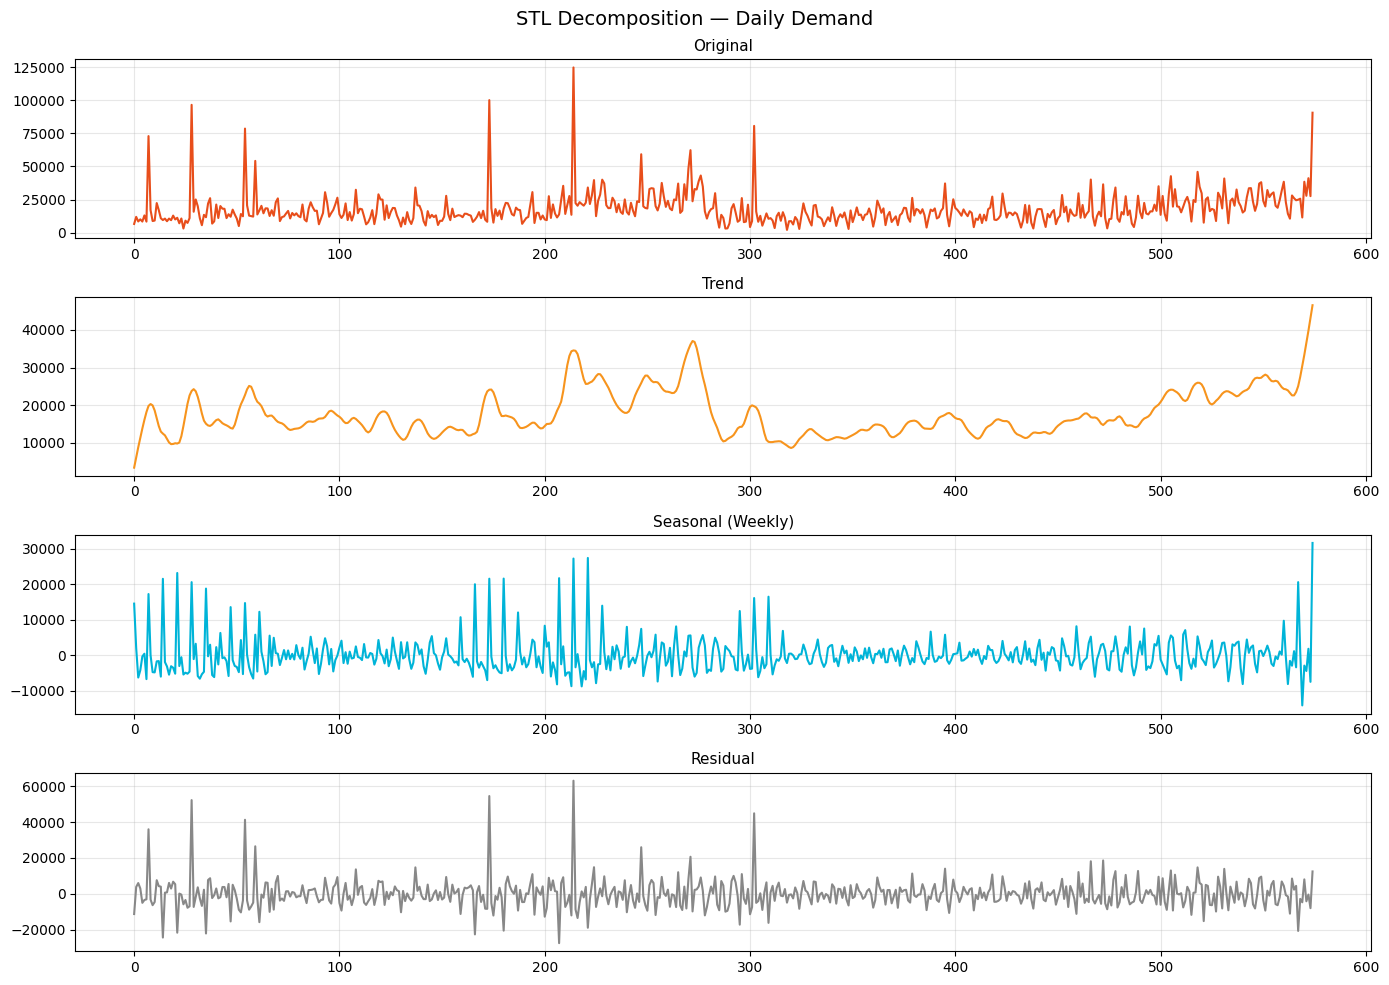

Saved: reports/stl_decomposition.png


In [5]:
# STL decomposition to separate trend, seasonality, and residual
stl    = STL(ts.dropna(), period=7)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

components  = [ts, result.trend, result.seasonal, result.resid]
labels      = ['Original', 'Trend', 'Seasonal (Weekly)', 'Residual']
colors_list = ['#E84E1B', '#F7941D', '#00B4D8', '#888888']

for ax, data, label, color in zip(axes, components, labels, colors_list):
    ax.plot(data.values, color=color, linewidth=1.5)
    ax.set_title(label, fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('STL Decomposition — Daily Demand', fontsize=14)
plt.tight_layout()
plt.savefig(r'../reports/stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/stl_decomposition.png")

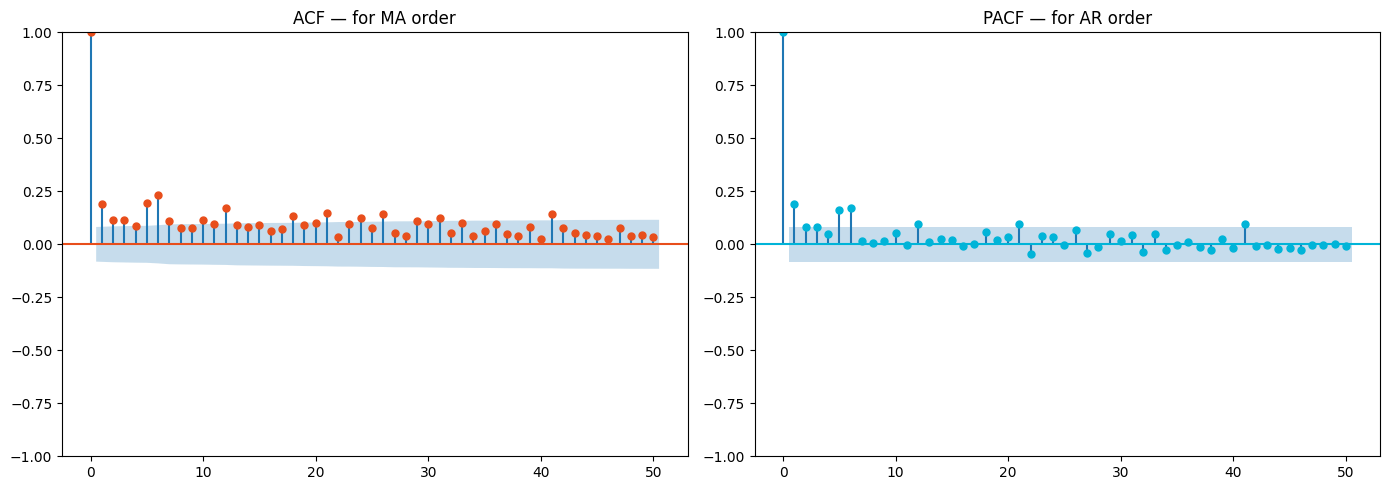

Saved: reports/acf_pacf.png


In [6]:
# ACF and PACF plots to determine MA and AR orders for forecasting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(ts.dropna(), lags=50, ax=axes[0], color='#E84E1B')
axes[0].set_title('ACF — for MA order')

plot_pacf(ts.dropna(), lags=50, ax=axes[1], color='#00B4D8')
axes[1].set_title('PACF — for AR order')

plt.tight_layout()
plt.savefig(r'../reports/acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/acf_pacf.png")

In [7]:
# log all EDA metrics and artifacts to MLflow
with mlflow.start_run(run_name='EDA_TimeSeries'):
    mlflow.log_metric('adf_pvalue',  round(adf_result[1], 4))
    mlflow.log_metric('kpss_pvalue', round(kpss_result[1], 4))
    mlflow.log_metric('mean_demand', round(ts.mean(), 2))
    mlflow.log_metric('std_demand',  round(ts.std(), 2))

    mlflow.log_artifact(r'../reports/stl_decomposition.png')
    mlflow.log_artifact(r'../reports/acf_pacf.png')

    print("=== EDA SUMMARY ===")
    print(f"ADF p-value  : {adf_result[1]:.4f}")
    print(f"KPSS p-value : {kpss_result[1]:.4f}")
    print(f"Mean demand  : {ts.mean():.0f}")
    print(f"Std demand   : {ts.std():.0f}")
    print("\nEDA Complete!")

=== EDA SUMMARY ===
ADF p-value  : 0.0000
KPSS p-value : 0.0704
Mean demand  : 17704
Std demand   : 12120

EDA Complete!
🏃 View run EDA_TimeSeries at: http://localhost:5000/#/experiments/3/runs/27b98d0533054a42b259d272af19028a
🧪 View experiment at: http://localhost:5000/#/experiments/3
